<a href="https://colab.research.google.com/github/ashishkumar100907/git/blob/main/quickstarts/Get_started_managed_agents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2026 Google LLC.

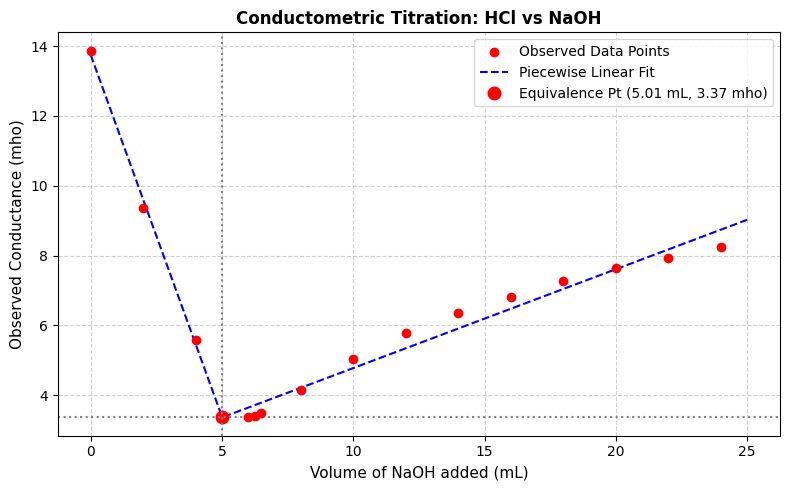

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data from your observation sheet
v = np.array([0, 2, 4, 6, 6.25, 6.5, 8, 10, 12, 14, 16, 18, 20, 22, 24])
g = np.array([13.87, 9.35, 5.58, 3.38, 3.41, 3.48, 4.16, 5.03, 5.77, 6.35, 6.81, 7.26, 7.64, 7.93, 8.24])

# Piecewise linear regression model
def piecewise_linear(x, x0, y0, m1, m2):
    return np.piecewise(x, [x < x0], [lambda x: m1 * (x - x0) + y0, lambda x: m2 * (x - x0) + y0])

# Perform piecewise fit
popt, _ = curve_fit(piecewise_linear, v, g, p0=[5.5, 3.5, -1.8, 0.3])

# Plotting with mL and mho units
plt.figure(figsize=(8, 5))
plt.scatter(v, g, color='red', label='Observed Data Points', zorder=5)

x_fit = np.linspace(0, 25, 200)
plt.plot(x_fit, piecewise_linear(x_fit, *popt), 'b--', label='Piecewise Linear Fit')
plt.plot(popt[0], popt[1], 'ro', markersize=9, label=f'Equivalence Pt ({popt[0]:.2f} mL, {popt[1]:.2f} mho)')

plt.axvline(x=popt[0], color='gray', linestyle=':', linewidth=1.5)
plt.axhline(y=popt[1], color='gray', linestyle=':', linewidth=1.5)

plt.title('Conductometric Titration: HCl vs NaOH', fontsize=12, fontweight='bold')
plt.xlabel('Volume of NaOH added (mL)', fontsize=11)
plt.ylabel('Observed Conductance (mho)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()